##**1. 데이터 분석**

데이터 셋 가져오기

In [ ]:
# 1. Kaggle 설치
!pip install -q kaggle

# 2. 토큰 저장
!mkdir -p ~/.kaggle
!echo "KAGGLE_API_KEY" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

# 3. 데이터셋 다운로드
!kaggle datasets download -d msambare/fer2013

# 4. 압축 해제
!unzip -q fer2013.zip -d fer2013

# 5. 폴더 확인
!ls fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 134MB/s]

test  train


데이터 셋 확인

In [ ]:
# 데이터 개수 확인
import os

# 1. 학습 데이터 이미지 개수 확인
train_count = 0
for category in os.listdir("fer2013/train"):
    category_path = os.path.join("fer2013/train", category)
    train_count += len(os.listdir(category_path))

# 2. 테스트 데이터 이미지 개수 확인
test_count = 0
for category in os.listdir("fer2013/test"):
    category_path = os.path.join("fer2013/test", category)
    test_count += len(os.listdir(category_path))

# 3. 카테고리 별 이미지 개수 확인
categories = sorted(os.listdir("fer2013/train"))
counts = []
for category in categories:
    path = os.path.join("fer2013/train", category)
    counts.append(len(os.listdir(path)))

# 4. 출력하기
print(f'학습셋 이미지 수: {train_count}개')
print(f'테스트셋 이미지 수: {test_count}개')
print("카테고리별 이미지 수")
for category, count in zip (categories, counts):
    print(f'- {category}: {count}개')


학습셋 이미지 수: 28709개
테스트셋 이미지 수: 7178개
카테고리별 이미지 수
- angry: 3995개
- disgust: 436개
- fear: 4097개
- happy: 7215개
- neutral: 4965개
- sad: 4830개
- surprise: 3171개


(48, 48)


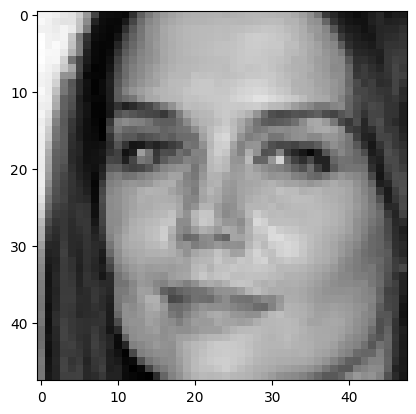

In [ ]:
# 첫번째 이미지 확인
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

happy_folder = "fer2013/train/happy"

first_file = os.listdir(happy_folder)[0]

img = Image.open(os.path.join(happy_folder, first_file))

print(img.size)
plt.imshow(img, cmap='gray')
plt.show()

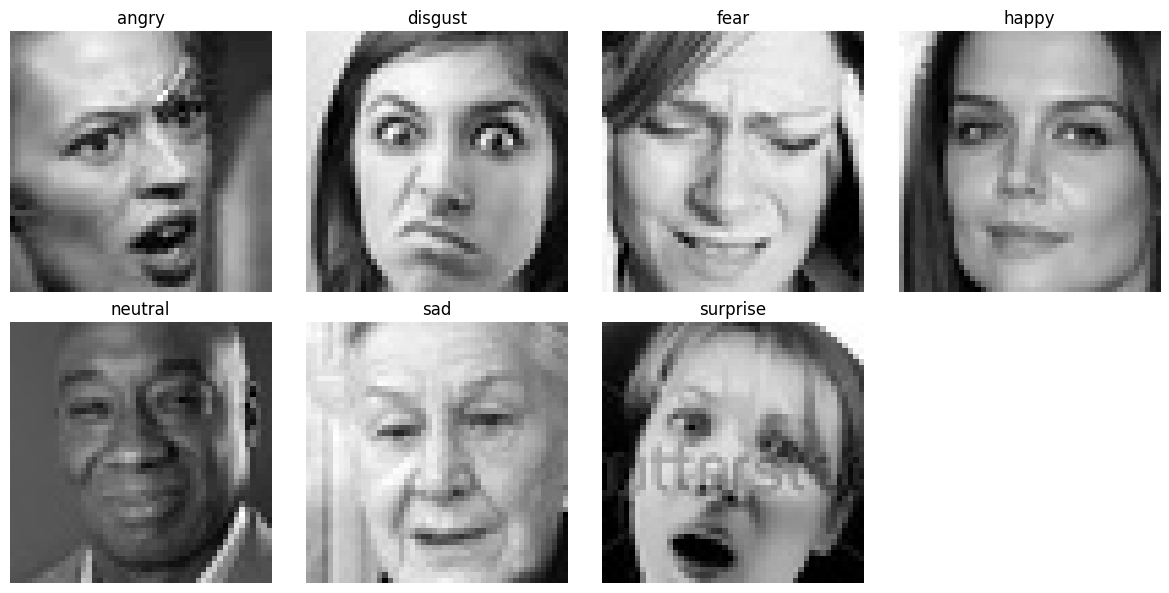

In [ ]:
# 각 카테고리별 사진
plt.figure(figsize=(12,6))

for i, category in enumerate(categories):
    folder = os.path.join("fer2013/train", category)

    file = os.listdir(folder)[0]

    img = Image.open(os.path.join(folder, file))

    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 라이브러리 임포트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.utils import shuffle

import matplotlib.pyplot as plt
import numpy as np

학습셋과 테스트셋 나누기

In [ ]:
# 1. train, test 리스트 생성
X_train = []
Y_train = []

X_test = []
Y_test = []

# 2. 각 폴더 읽기
train_dir = "fer2013/train"
test_dir = "fer2013/test"

# 3. train 리스트에 저장
for label, category in enumerate(categories):
    folder = os.path.join(train_dir, category)
    for file in os.listdir(folder):
        img = Image.open(os.path.join(folder, file))
        img = img.convert('RGB').resize((96,96))
        img_array = np.array(img)
        X_train.append(img_array)
        Y_train.append(label)

# test 리스트에 저장
for label, category in enumerate(categories):
    folder = os.path.join(test_dir, category)
    for file in os.listdir(folder):
        img = Image.open(os.path.join(folder, file))
        img = img.convert('RGB').resize((96,96))
        img_array = np.array(img)
        X_test.append(img_array)
        Y_test.append(label)

# 4. numpy 배열로 변환
X_train = np.array(X_train)
Y_train = np.array(Y_train)

X_test = np.array(X_test)
Y_test = np.array(Y_test)

# 5. 데이터 섞기
X_train, Y_train = shuffle(X_train, Y_train, random_state = 42)
X_test, Y_test = shuffle(X_test, Y_test, random_state = 42)

# 6. 데이터 크기 맞추기
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
Y_train = to_categorical(Y_train, 7)
Y_test = to_categorical(Y_test, 7)

In [ ]:
print(f"데이터: 학습용 {X_train.shape[0]}개, 테스트용 {X_test.shape[0]}개")
print("학습 데이터 형태:", X_train.shape)
print("이미지 1장의 형태:", X_train[0].shape)
print("학습 데이터 라벨 형태:", Y_train.shape)

데이터: 학습용 28709개, 테스트용 7178개
학습 데이터 형태: (28709, 96, 96, 3)
이미지 1장의 형태: (96, 96, 3)
학습 데이터 라벨 형태: (28709, 7)


In [ ]:
labels = np.argmax(Y_train, axis=1)

print(labels[:20])
print(labels[-20:])

[2 3 6 2 6 2 0 5 0 4 3 5 4 3 2 4 5 6 0 6]
[0 0 2 4 6 3 6 3 5 1 4 2 5 3 3 5 2 0 4 5]


## **2. 모델 설계**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet import MobileNet, preprocess_input as mobilenet_preprocess # 사전학습모델로 MobileNet 사용
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Data Augmentation을 위해서
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
# 모델 저장 경로 설정 (구글 드라이브 내 경로)
modelpath = "/content/drive/MyDrive/FER2013_MobileNet.keras"

def run_mobilenet_model(fine_tune_layers = 2):
    if os.path.exists(modelpath):
        print("\n[알림] 구글 드라이브에서 기존에 학습된 모델을 불러옵니다.")
        model = load_model(modelpath)
        base_model = model.layers[1]

    else:
        print("\n[알림] 기존 모델이 없으므로 새로운 모델을 생성합니다.")
        base_model = MobileNet(weights = 'imagenet', include_top=False, input_shape=(96,96,3))
        base_model.trainable = False

        inputs = Input(shape=(96, 96, 3))
        x = base_model(inputs, training = False)
        x = GlobalAveragePooling2D()(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(0.5)(x)
        outputs = Dense(7, activation='softmax')(x)
        model = Model(inputs, outputs)

    base_model.trainable = True
    for layer in base_model.layers[:-fine_tune_layers]:
        layer.trainable = False

    model.compile(loss='categorical_crossentropy', optimizer= Adam(1e-5), metrics=['accuracy'])
    return model

#### 학습 실행

In [ ]:
model = run_mobilenet_model(fine_tune_layers = 2)

checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights = True)


print("\n학습을 시작합니다...")
history = model.fit(X_train, Y_train, validation_split=0.2,
                    epochs=10, batch_size=64, verbose=1,
                    callbacks=[early_stopping_callback, checkpointer])

# 최종 테스트 정확도 출력
print("\n--- 학습 완료 ---")
score = model.evaluate(X_test, Y_test, verbose=0)
print("최종 테스트 정확도: %.4f" % score[1])


[알림] 기존 모델이 없으므로 새로운 모델을 생성합니다.


/tmp/ipykernel_647/65999887.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights = 'imagenet', include_top=False, input_shape=(96,96,3))



학습을 시작합니다...
Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1752 - loss: 3.0619
Epoch 1: val_loss improved from None to 2.07007, saving model to /content/drive/MyDrive/FER2013_MobileNet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FER2013_MobileNet.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 48s 86ms/step - accuracy: 0.1842 - loss: 2.8421 - val_accuracy: 0.2224 - val_loss: 2.0701
Epoch 2/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2062 - loss: 2.3649
Epoch 2: val_loss improved from 2.07007 to 1.89910, saving model to /content/drive/MyDrive/FER2013_MobileNet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FER2013_MobileNet.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.2128 - loss: 2.2897 - val_accuracy: 0.2631 - val_loss: 1.8991
Epoch 3/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2242 - loss: 2.1182
Epoch 3: val_loss improved from 1.89910 to 1.81650, saving model to /content/drive/MyDrive/FER201

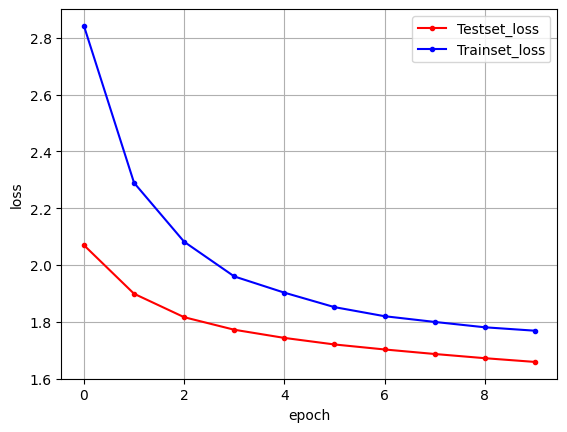

In [ ]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [ ]:
model = run_mobilenet_model(fine_tune_layers = 20)

checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights = True)


print("\n학습을 시작합니다...")
history = model.fit(X_train, Y_train, validation_split=0.2,
                    epochs=30, batch_size=64, verbose=1,
                    callbacks=[early_stopping_callback, checkpointer])

# 최종 테스트 정확도 출력
print("\n--- 학습 완료 ---")
score = model.evaluate(X_test, Y_test, verbose=0)
print("최종 테스트 정확도: %.4f" % score[1])


[알림] 구글 드라이브에서 기존에 학습된 모델을 불러옵니다.

학습을 시작합니다...
Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3047 - loss: 1.7623
Epoch 1: val_loss improved from None to 1.64603, saving model to /content/drive/MyDrive/FER2013_MobileNet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FER2013_MobileNet.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.3099 - loss: 1.7554 - val_accuracy: 0.3727 - val_loss: 1.6460
Epoch 2/30
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3163 - loss: 1.7438
Epoch 2: val_loss improved from 1.64603 to 1.63220, saving model to /content/drive/MyDrive/FER2013_MobileNet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FER2013_MobileNet.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3178 - loss: 1.7404 - val_accuracy: 0.3772 - val_loss: 1.6322
Epoch 3/30
356/359 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3172 - loss: 1.7288
Epoch 3: val_loss improved from 1.63220 to 1.62085, saving mod

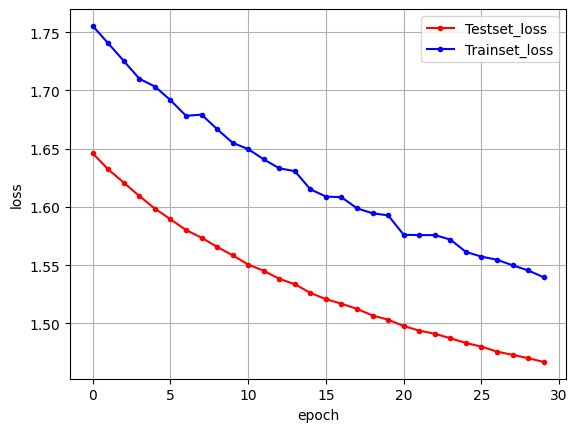

In [ ]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [ ]:
model = run_mobilenet_model(fine_tune_layers = 40)

checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights = True)


print("\n학습을 시작합니다...")
history = model.fit(X_train, Y_train, validation_split=0.2,
                    epochs=30, batch_size=64, verbose=1,
                    callbacks=[early_stopping_callback, checkpointer])

# 최종 테스트 정확도 출력
print("\n--- 학습 완료 ---")
score = model.evaluate(X_test, Y_test, verbose=0)
print("최종 테스트 정확도: %.4f" % score[1])


[알림] 구글 드라이브에서 기존에 학습된 모델을 불러옵니다.

학습을 시작합니다...
Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4090 - loss: 1.5410
Epoch 1: val_loss improved from None to 1.46375, saving model to /content/drive/MyDrive/FER2013_MobileNet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FER2013_MobileNet.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.4090 - loss: 1.5420 - val_accuracy: 0.4497 - val_loss: 1.4637
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4113 - loss: 1.5335
Epoch 2: val_loss improved from 1.46375 to 1.46176, saving model to /content/drive/MyDrive/FER2013_MobileNet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FER2013_MobileNet.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4073 - loss: 1.5342 - val_accuracy: 0.4485 - val_loss: 1.4618
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4223 - loss: 1.5243
Epoch 3: val_loss improved from 1.46176 to 1.45815, saving mod

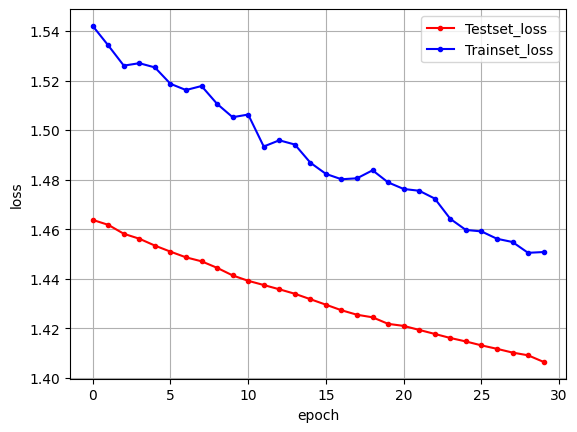

In [ ]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [ ]:
model = run_mobilenet_model(fine_tune_layers = 40)

checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights = True)


print("\n학습을 시작합니다...")
history = model.fit(X_train, Y_train, validation_split=0.2,
                    epochs=50, batch_size=64, verbose=1,
                    callbacks=[early_stopping_callback, checkpointer])

# 최종 테스트 정확도 출력
print("\n--- 학습 완료 ---")
score = model.evaluate(X_test, Y_test, verbose=0)
print("최종 테스트 정확도: %.4f" % score[1])


[알림] 구글 드라이브에서 기존에 학습된 모델을 불러옵니다.

학습을 시작합니다...
Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4443 - loss: 1.4473
Epoch 1: val_loss improved from None to 1.40542, saving model to /content/drive/MyDrive/FER2013_MobileNet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FER2013_MobileNet.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.4458 - loss: 1.4488 - val_accuracy: 0.4671 - val_loss: 1.4054
Epoch 2/50
355/359 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4570 - loss: 1.4263
Epoch 2: val_loss improved from 1.40542 to 1.40431, saving model to /content/drive/MyDrive/FER2013_MobileNet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FER2013_MobileNet.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4498 - loss: 1.4403 - val_accuracy: 0.4671 - val_loss: 1.4043
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4479 - loss: 1.4332
Epoch 3: val_loss improved from 1.40431 to 1.40384, saving mod

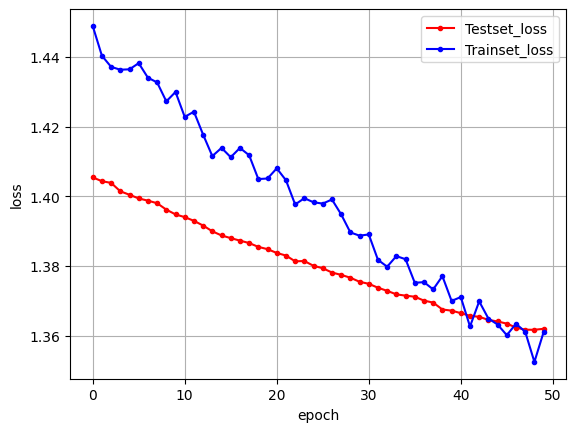

In [ ]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [ ]:
model = run_mobilenet_model(fine_tune_layers = 40)

checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights = True)


print("\n학습을 시작합니다...")
history = model.fit(X_train, Y_train, validation_split=0.2,
                    epochs=10, batch_size=64, verbose=1,
                    callbacks=[early_stopping_callback, checkpointer])

# 최종 테스트 정확도 출력
print("\n--- 학습 완료 ---")
score = model.evaluate(X_test, Y_test, verbose=0)
print("최종 테스트 정확도: %.4f" % score[1])


[알림] 구글 드라이브에서 기존에 학습된 모델을 불러옵니다.

학습을 시작합니다...
Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4859 - loss: 1.3461
Epoch 1: val_loss improved from None to 1.36146, saving model to /content/drive/MyDrive/FER2013_MobileNet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FER2013_MobileNet.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 48s 86ms/step - accuracy: 0.4833 - loss: 1.3543 - val_accuracy: 0.4807 - val_loss: 1.3615
Epoch 2/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4814 - loss: 1.3545
Epoch 2: val_loss improved from 1.36146 to 1.36139, saving model to /content/drive/MyDrive/FER2013_MobileNet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FER2013_MobileNet.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - accuracy: 0.4820 - loss: 1.3496 - val_accuracy: 0.4805 - val_loss: 1.3614
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4837 - loss: 1.3561
Epoch 3: val_loss improved from 1.36139 to 1.35991, saving mo

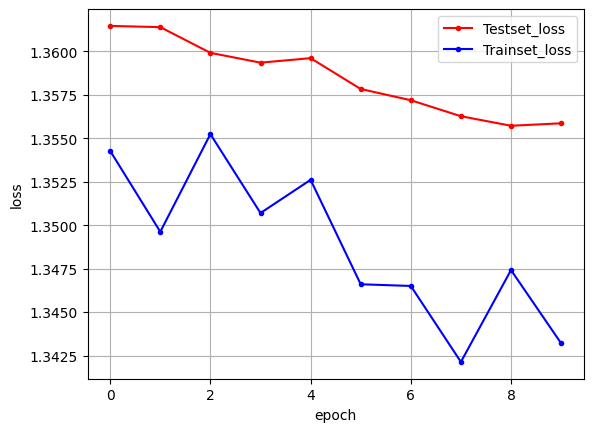

In [ ]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [ ]:
model = load_model(modelpath)

# 현재 저장된 모델 상태 확인
score = model.evaluate(X_test, Y_test, verbose=0)
print("테스트 정확도: %.4f" % score[1])

# 어떤 층이 열려있는지 확인
base_model = model.layers[1]
for i, layer in enumerate(base_model.layers):
    print(f"{i}: {layer.name} - trainable: {layer.trainable}")

테스트 정확도: 0.4790
0: input_layer_2 - trainable: True
1: conv1 - trainable: False
2: conv1_bn - trainable: False
3: conv1_relu - trainable: False
4: conv_dw_1 - trainable: False
5: conv_dw_1_bn - trainable: False
6: conv_dw_1_relu - trainable: False
7: conv_pw_1 - trainable: False
8: conv_pw_1_bn - trainable: False
9: conv_pw_1_relu - trainable: False
10: conv_pad_2 - trainable: False
11: conv_dw_2 - trainable: False
12: conv_dw_2_bn - trainable: False
13: conv_dw_2_relu - trainable: False
14: conv_pw_2 - trainable: False
15: conv_pw_2_bn - trainable: False
16: conv_pw_2_relu - trainable: False
17: conv_dw_3 - trainable: False
18: conv_dw_3_bn - trainable: False
19: conv_dw_3_relu - trainable: False
20: conv_pw_3 - trainable: False
21: conv_pw_3_bn - trainable: False
22: conv_pw_3_relu - trainable: False
23: conv_pad_4 - trainable: False
24: conv_dw_4 - trainable: False
25: conv_dw_4_bn - trainable: False
26: conv_dw_4_relu - trainable: False
27: conv_pw_4 - trainable: False
28: conv_pw_4

In [ ]:
model = run_mobilenet_model(fine_tune_layers = 40)

checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights = True)


print("\n학습을 시작합니다...")
history = model.fit(X_train, Y_train, validation_split=0.2,
                    epochs=10, batch_size=64, verbose=1,
                    callbacks=[early_stopping_callback, checkpointer])

# 최종 테스트 정확도 출력
print("\n--- 학습 완료 ---")
score = model.evaluate(X_test, Y_test, verbose=0)
print("최종 테스트 정확도: %.4f" % score[1])


[알림] 구글 드라이브에서 기존에 학습된 모델을 불러옵니다.

학습을 시작합니다...
Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4766 - loss: 1.3650
Epoch 1: val_loss improved from None to 1.23989, saving model to /content/drive/MyDrive/FER2013_MobileNet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FER2013_MobileNet.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 47s 85ms/step - accuracy: 0.4726 - loss: 1.3724 - val_accuracy: 0.5313 - val_loss: 1.2399
Epoch 2/10
355/359 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4766 - loss: 1.3730
Epoch 2: val_loss improved from 1.23989 to 1.23975, saving model to /content/drive/MyDrive/FER2013_MobileNet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FER2013_MobileNet.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4776 - loss: 1.3682 - val_accuracy: 0.5319 - val_loss: 1.2397
Epoch 3/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4827 - loss: 1.3657
Epoch 3: val_loss did not improve from 1.23975
359/359 ━━━━━━━

## **3. 학습 과정 모니터링**

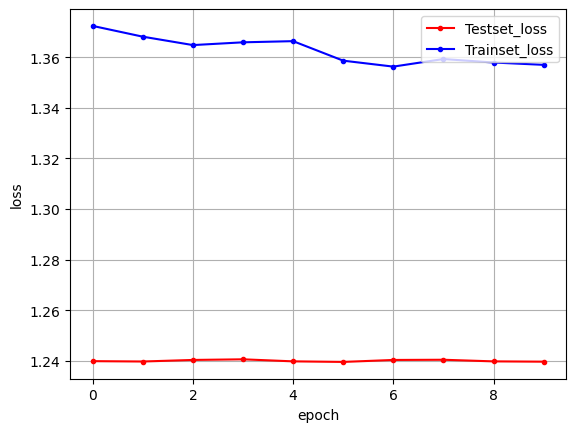

In [ ]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

##**4. 성능 평가 및 오류 분석**

In [ ]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

true_labels = np.argmax(Y_test, axis=1)

print(predictions)
print(predicted_labels)
print(true_labels)

225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step
[[0.03276569 0.00529539 0.1815302  ... 0.42070523 0.06263839 0.08431708]
 [0.19160451 0.03889161 0.17271422 ... 0.08244766 0.14530721 0.02225537]
 [0.10188302 0.01976007 0.2077208  ... 0.07689043 0.33094913 0.00564552]
 ...
 [0.12377964 0.00181486 0.03626129 ... 0.5465073  0.1576234  0.02086649]
 [0.17941238 0.0344052  0.12064165 ... 0.30766886 0.14054272 0.06316157]
 [0.06138723 0.00609055 0.05121259 ... 0.06646385 0.05519091 0.08076987]]
[4 3 5 ... 4 4 3]
[4 3 4 ... 5 5 0]


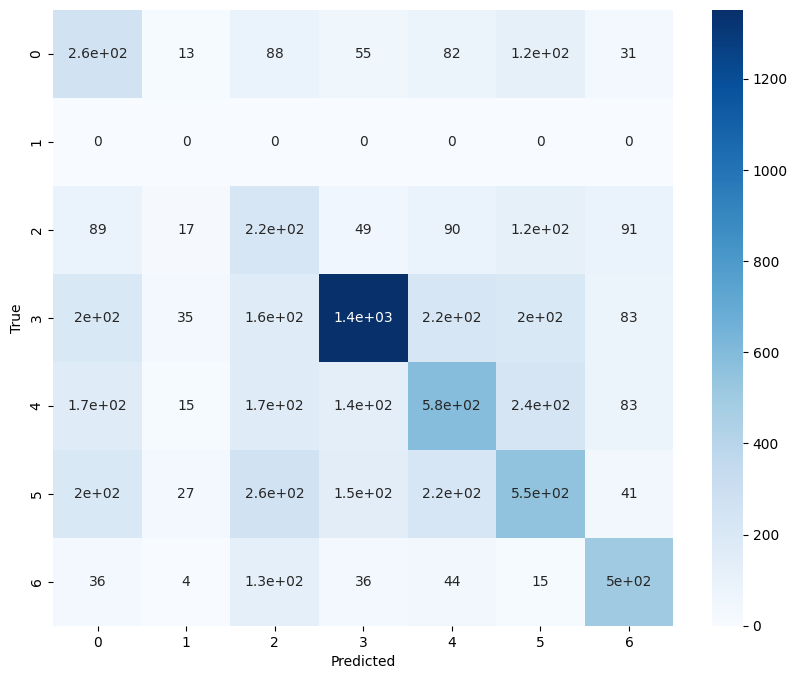

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(predicted_labels, true_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
from sklearn.metrics import f1_score


# Macro 평균
f1_macro = f1_score(true_labels, predicted_labels, average='macro')
print(f"Macro F1 Score: {f1_macro:.4f}")

# Weighted 평균
f1_weighted = f1_score(true_labels, predicted_labels, average='weighted')
print(f"Weighted F1 Score: {f1_weighted:.4f}")


Macro F1 Score: 0.3904
Weighted F1 Score: 0.4657


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

cr = classification_report(true_labels, predicted_labels, target_names = categories)
cr

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'              precision    recall  f1-score   support\n\n       angry       0.40      0.27      0.32       958\n     disgust       0.00      0.00      0.00       111\n        fear       0.32      0.21      0.26      1024\n       happy       0.60      0.76      0.67      1774\n     neutral       0.42      0.47      0.44      1233\n         sad       0.38      0.44      0.41      1247\n    surprise       0.65      0.60      0.63       831\n\n    accuracy                           0.48      7178\n   macro avg       0.40      0.39      0.39      7178\nweighted avg       0.46      0.48      0.47      7178\n'

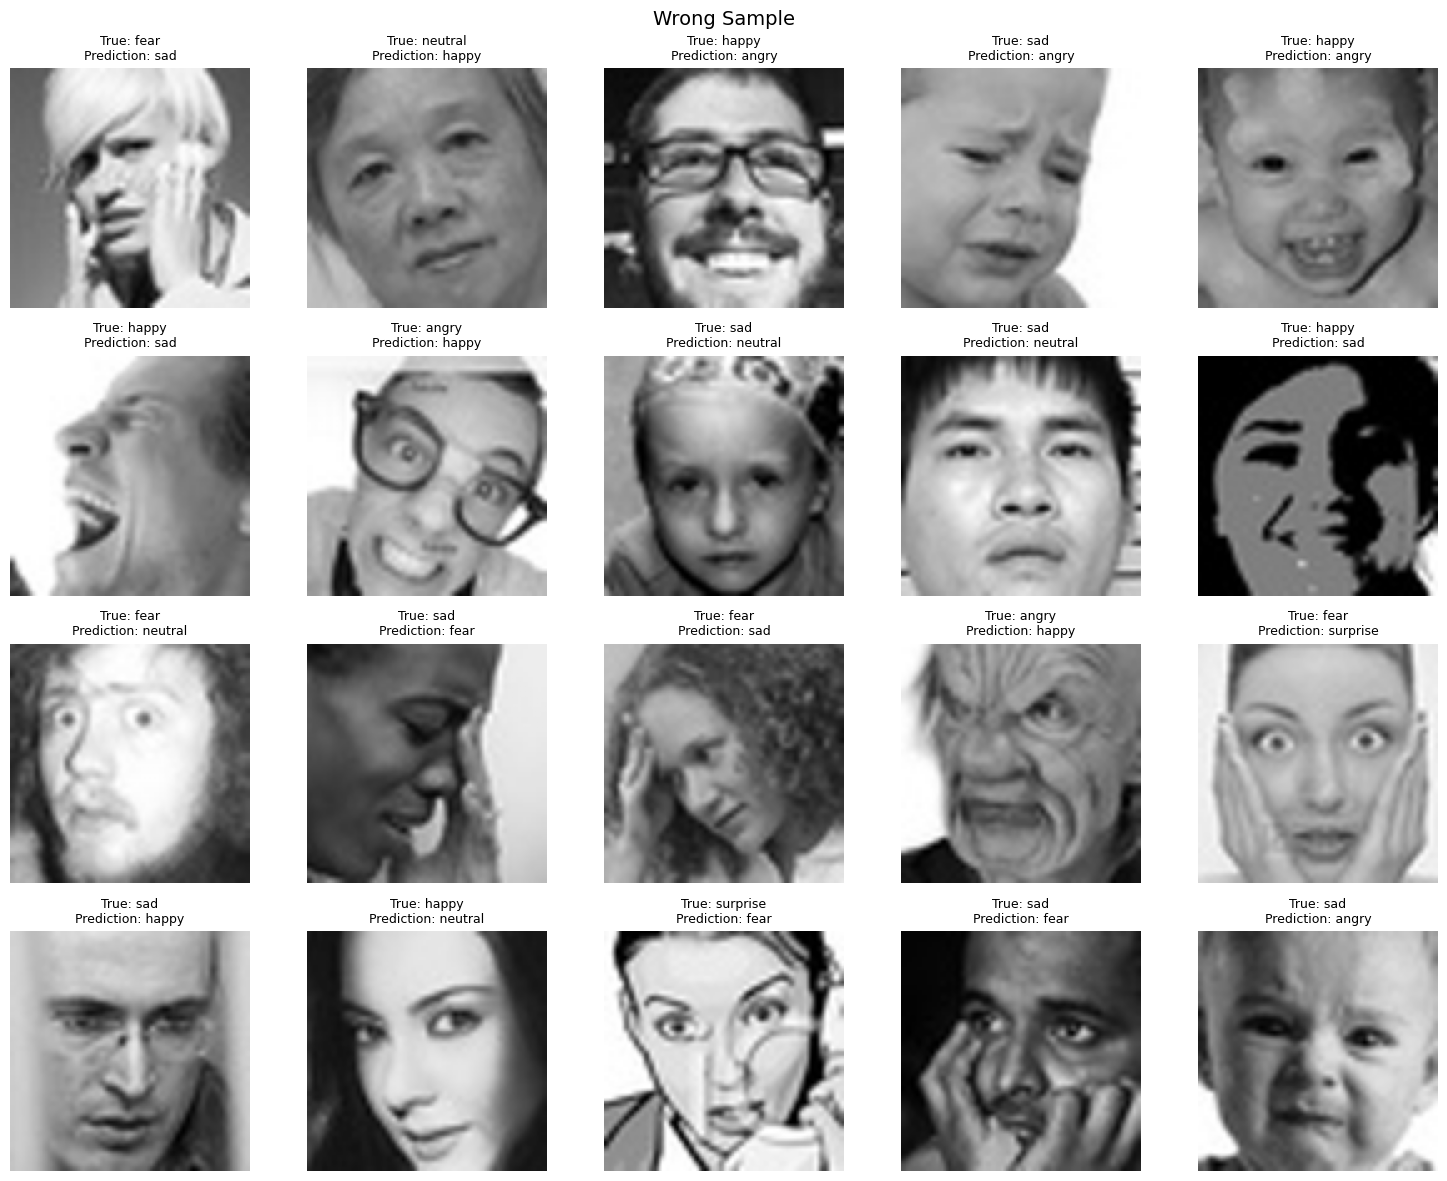

In [ ]:
emotion_labels = categories

# 틀린 인덱스 추출
wrong_idx = np.where(predicted_labels != true_labels)[0]

# 20개만 랜덤 샘플
sample_idx = np.random.choice(wrong_idx, size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    axes[i].imshow(X_test[idx])
    axes[i].set_title(
        f"True: {emotion_labels[true_labels[idx]]}\nPrediction: {emotion_labels[predicted_labels[idx]]}",
        fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('Wrong Sample', fontsize=14)
plt.tight_layout()
plt.show()